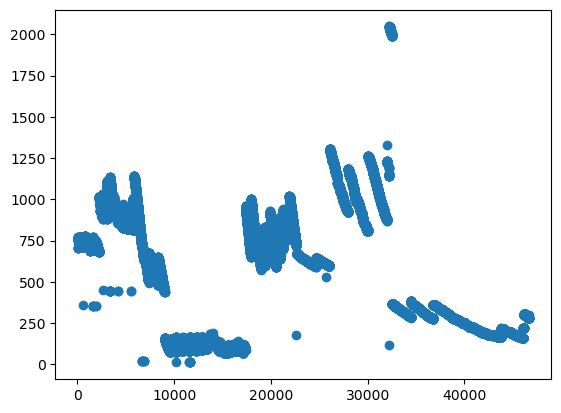

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
data = pd.read_csv("./feeds.csv")

#SPLIT THE DATASET INTO TWO FILES FROM THE 30-minute to 5-minute SWITCH
# data_30 = data.iloc[:22673]
# data_5 = data.iloc[22673:]

# data_30.to_csv("feeds_30.csv", index=False)
# data_5.to_csv("feeds_5.csv", index=False)
data_5 = pd.read_csv("feeds_5.csv")
data_30 = pd.read_csv("feeds_30.csv")


#BASIC FUNCTION FOR FILTERING OUT VALUES NEAR 10
def pickfield(data, field_nr):
    field = data[data[field_nr]>10]
    #field.head()
    
    return field

#PLOT WHOLE FIELD, TO SEE WHOLE DATASET IN THE BEGINNING TO GET AN IDEA, WHAT IT LOOKS LIKE
def plotfield(field_nr):
    field = pickfield(data, field_nr)
    
    ax = plt.gca()
    ax.scatter(x=field["entry_id"], y=field[field_nr])
    #ax.set_yscale('log')
plotfield("field6")

                            OLS Regression Results                            
Dep. Variable:                 field7   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.827e+06
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        16:20:23   Log-Likelihood:                -1335.5
No. Observations:                1999   AIC:                             2675.
Df Residuals:                    1997   BIC:                             2686.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1637.3190      0.820   1996.971      0.0

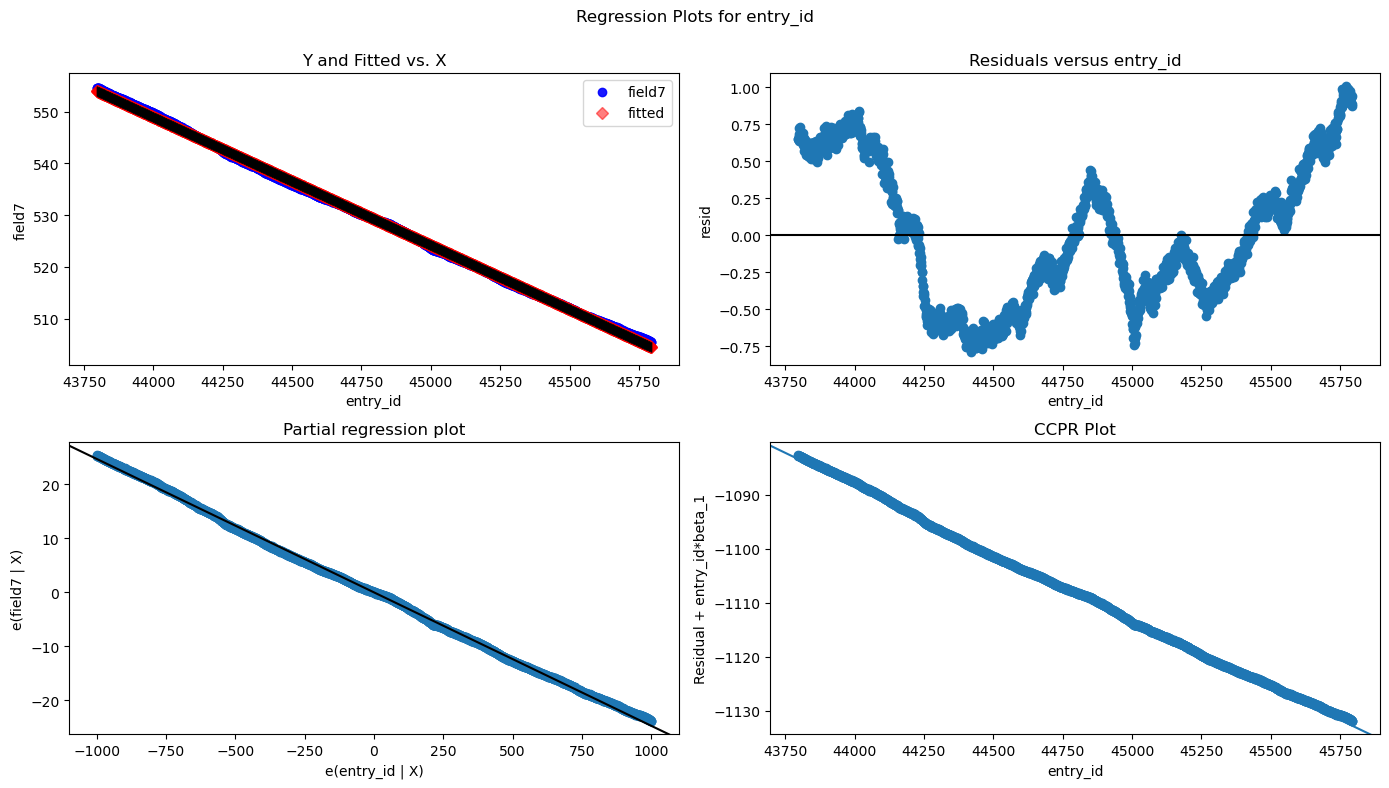

In [9]:
import seaborn as sns
import statsmodels.api as sm  
from statsmodels.formula.api import ols 

#This is a really important function for selecting a range of points to analyse
def select_range(data, field_nr, start, end):
    field = pickfield(data, field_nr)
    #print(field.head())
    field = field[field["entry_id"] > start]
    field = field[field["entry_id"] < end]
    return field

#This function uses OLS regression and analyses it for a certain range. It is an easy way to see the residual graph and much info on it
def residual_graph(field_nr, start, end):

    data_field = select_range(data, field_nr, start, end)
    
    lm = ols(f'{field_nr} ~ entry_id', data=data_field).fit()
    print(lm.summary()) 
    fig = plt.figure(figsize=(14, 8))
    fig = sm.graphics.plot_regress_exog(lm, 'entry_id', fig=fig)  

residual_graph("field7", 43795 ,45795)


Cycle lengths: [1931 2010 1964 2221 1703 2800 1980 2017 3052 2000]


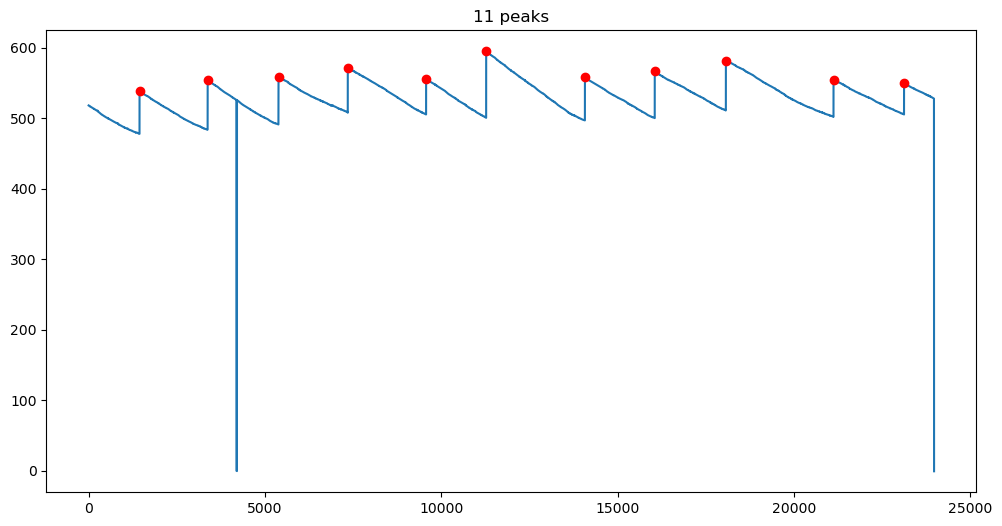

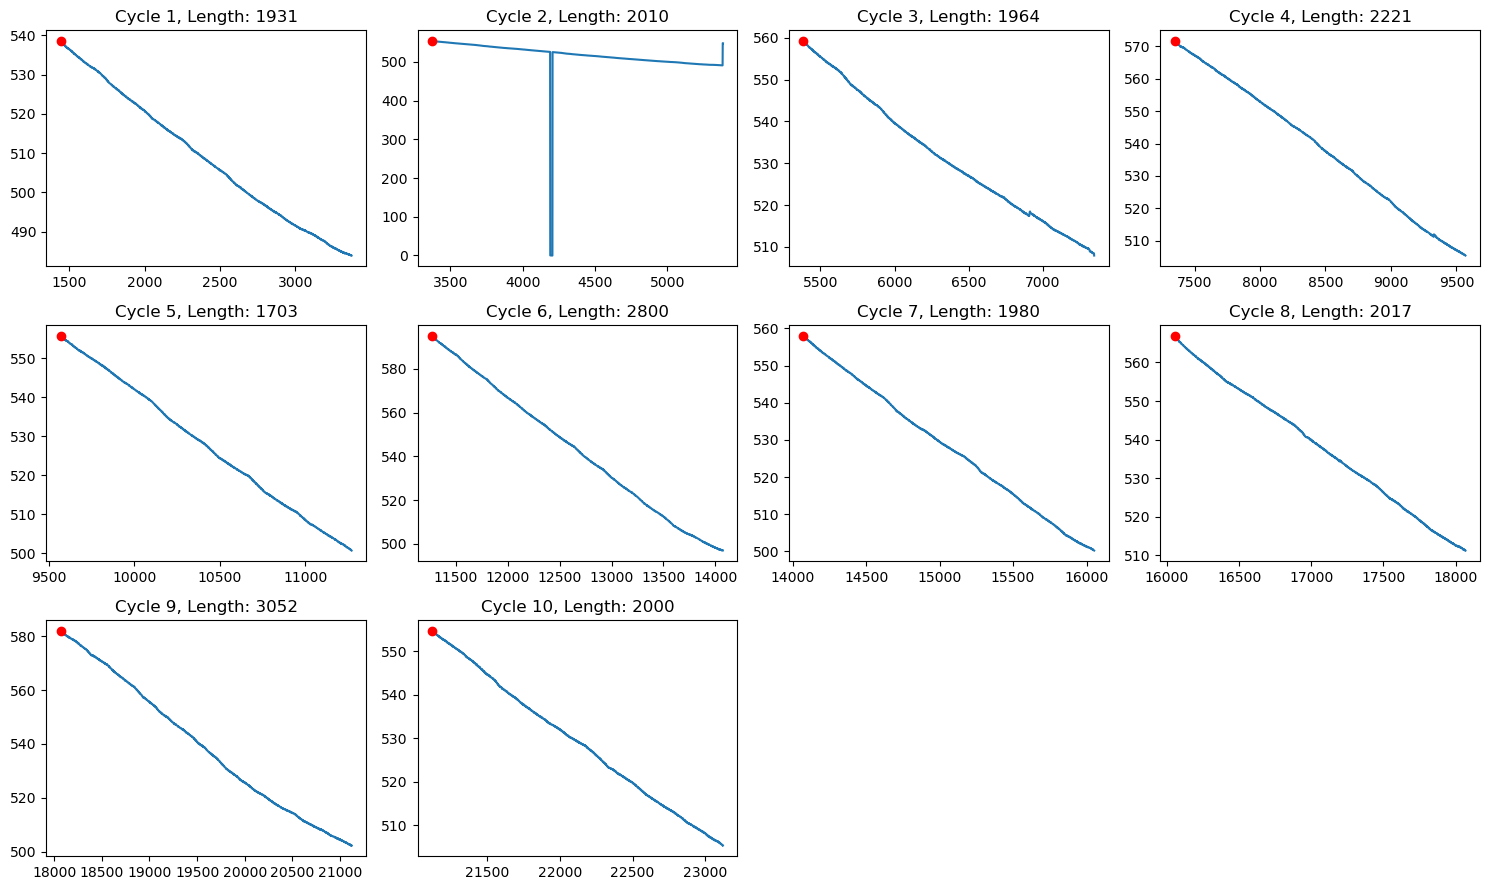

In [8]:
#THIS CODE IS ONE FORM OF TRYING TO FIND THE PEAKS TO FILTER OUT WATERING CYCLES
from scipy.signal import find_peaks

y = data_5[data_5["entry_id"] >22000]["field7"]
y = y.reset_index(drop=True)
x = np.arange(len(y))



peaks, _ = find_peaks(y, distance=1000, prominence=0.5)   # distance prevents false peaks, so does prominence


cycle_lengths = np.diff(peaks)

print("Cycle lengths:", cycle_lengths)
plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.plot(x[peaks], y[peaks], "ro")
plt.title(f"{len(peaks)} peaks")

cycles = len(peaks)-1

if cycles>0:
    n_cols = 4
    n_rows = int(np.ceil(cycles/n_cols))

    plt.figure(figsize=(15,3*n_rows))
    for i in range(cycles):
        start = peaks[i]
        end = peaks[i+1]
        plt.subplot(n_rows, n_cols, i+1)
        plt.plot(x[start:end], y[start:end])
        plt.plot(x[start], y[start], "ro")
        plt.title(f"Cycle {i+1}, Length: {cycle_lengths[i]}")
        
        plt.tight_layout()
plt.show()

In [ ]:
#This was a method we tried to analyse detecting breaking points. It was not really useful sadly

#!pip install piecewise-regression
import piecewise_regression
fieldsmall = select_range(data_5, "field7", 43795,45795)
pw_fit = piecewise_regression.Fit(list(fieldsmall["entry_id"]), list(fieldsmall["field7"]), n_breakpoints=1)
pw_fit.summary()

pw_fit.plot_data(color="grey", s=20)
pw_fit.plot_fit(color="red", linewidth=4)
pw_fit.plot_breakpoints()
pw_fit.plot_breakpoint_confidence_intervals()
plt.xlabel("x")
plt.ylabel("y")
plt.show()
plt.close()

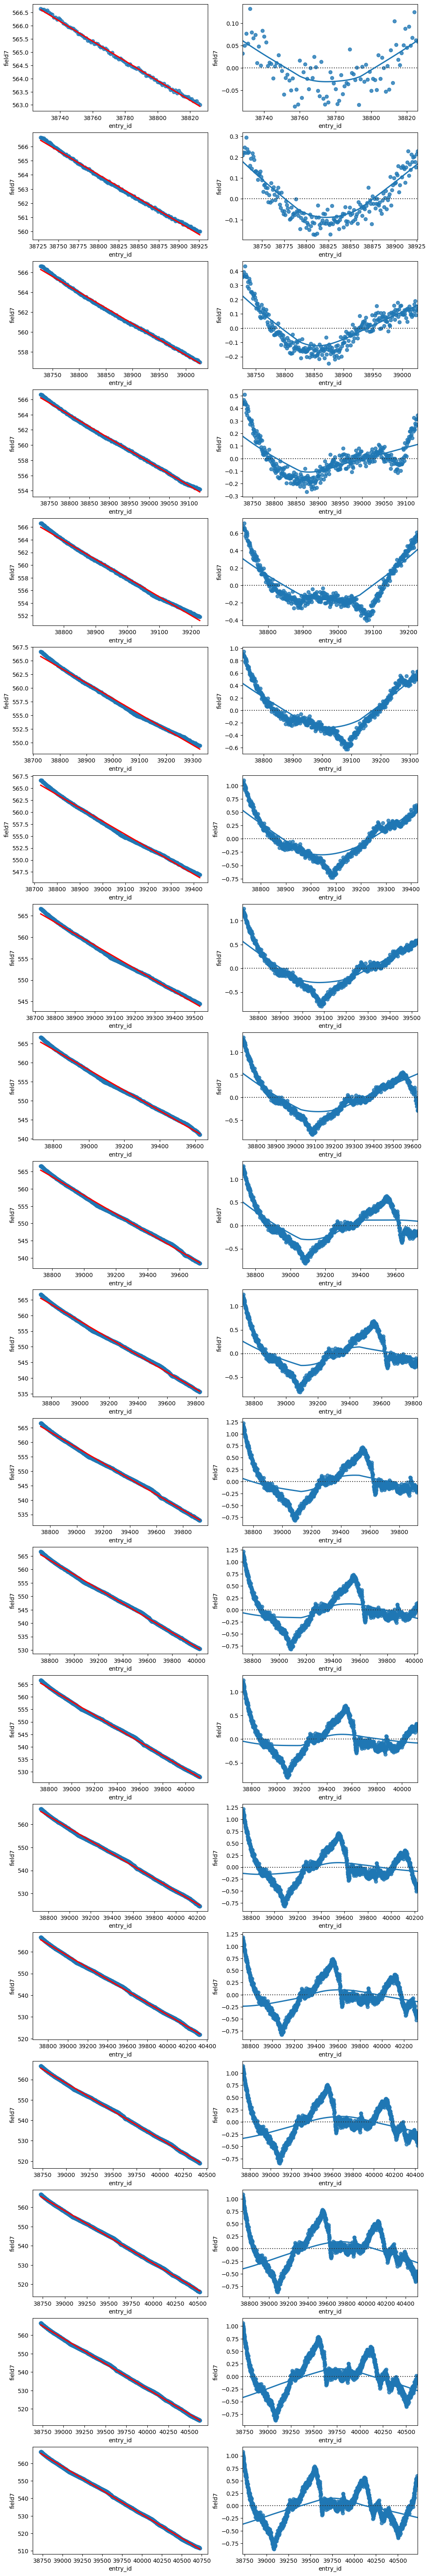

In [10]:
#Since a lot of the work was done analysing residuals, this code splits the cycle into 20 chunks
#This is done to see, how the residuals and the linear regression fit change

lower = 38727 #30023 40744 36747
upper = 40744 #32244 43796 38727
diff = upper-lower
chunks = 20 #HOW MANY GRAPHS TO MAKE // SECTIONS TO ANALYSE

fig, axs = plt.subplots(chunks, 2, figsize=(12, chunks*4))
for i in range(chunks):
    chunkdiff = diff//chunks
    currentlower = lower + i*chunkdiff
    currentupper = lower + (i+1)*chunkdiff 
    field = select_range(data, "field7",lower, currentupper)


    sns.regplot(x='entry_id', y='field7', data=field, order = 1, line_kws=dict(color="r"), ax=axs[i,0], ci = None)
    sns.residplot(x='entry_id', y='field7', data=field, order = 1, ax=axs[i, 1], lowess = True)

In [11]:
#This code's purpose was to determine, if a certain data point was gathered at day or at night
#this was done, since plants actually work quite differently when they are exposed to sunlight vs when they are not
#However we sadly did not use any of this data for our models, since we did not have the time to do so
#This code was written with the help of large language models.

#!pip install astral


from astral.sun import sun
from astral import LocationInfo

data_5 = pd.read_csv("feeds_5.csv")

def add_day_night_column(df, timestamp_col, location):
    
    
    df['timestamp'] = pd.to_datetime(df[timestamp_col], utc=True).dt.tz_convert(location.timezone)
    df['date'] = df['timestamp'].dt.date
    unique_dates = df['date'].unique()
    
    sun_times_map = {}
    for date in unique_dates:
        s = sun(location.observer, date=date)
        sun_times_map[date] = {'sunrise': s['sunrise'], 'sunset': s['sunset']}
        
    df['sunrise'] = df['date'].map(lambda x: sun_times_map[x]['sunrise'])
    df['sunset'] = df['date'].map(lambda x: sun_times_map[x]['sunset'])

    df['ToD'] = np.where(
        (df['timestamp'] >= df['sunrise']) & (df['timestamp'] < df['sunset']),
        'Day',
        'Night'
    )
    
    #clean up temporary columns
    df = df.drop(columns=['date', 'sunrise', 'sunset'])
    
    return df




#the info of the location
loc = LocationInfo(name="Tartu", region="Estonia", timezone="Europe/Tallinn",
                   latitude=58.3780, longitude=26.7290)


data_5 = add_day_night_column(data_5, timestamp_col='created_at', location=loc)

#Print out how many of the datapoints were classified as Day and Night
print(data_5["ToD"].value_counts())

ToD
Day      16002
Night     7972
Name: count, dtype: int64


<Axes: xlabel='entry_id', ylabel='field8'>

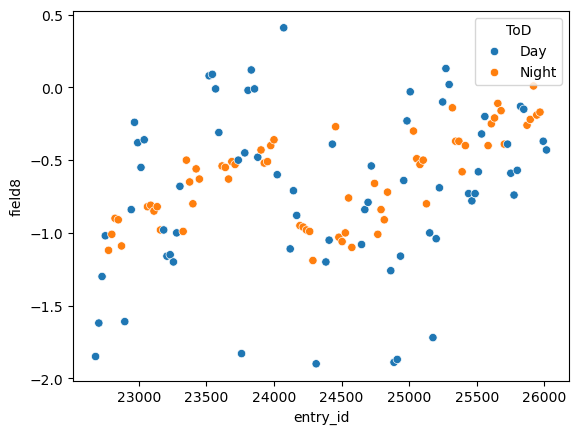

In [12]:
#RUN TOGETHER WITH LAST PARAGRAPH, THIS GRAPHS THE POINTS AND MAKES THE COLOR BE THE TIME OF DAY FOR A CERTAIN RANGE
#THIS ANALYSIS IS DONE ON THE DIFFERENCES OF MASS, NOT THE ABSOLUTE MASS OF THE PLANTS

field = select_range(data_5, "field8", 22674, 26050)
field['field8'] = (field['field8'].shift(-24) - field['field8'])
field = field[field["entry_id"] % 24 == 0]
field = field[field["field8"] > -2]
field = field[field["field8"] < 3]


sns.scatterplot(x='entry_id', y='field8', hue="ToD", data=field)